# Post-process trip data

## Install and import packages

In [1]:
#!pip install --upgrade seaborn
!pip install plotly

  Using cached plotly-6.4.0-py3-none-any.whl.metadata (8.5 kB)
Using cached plotly-6.4.0-py3-none-any.whl (9.9 MB)


In [2]:
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
import numpy as np
import pandas as pd
import os

## Utils

In [3]:
# Set SAVE equals to True, in order to Save cleaned trip data
SAVE = False

if SAVE:
    output_dir = f'./Data_saved/kl_scheduling/allRows_vin2/Generated_data_NO_shuffle/'
    file_path_csv = os.path.join(output_dir, f'EV_generated_data__trip_cleaned.csv')
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

## Data Inspection and Cleaning

### Load Synthetic Data

In [ ]:
##### Load trip data
#######trip_data = pd.read_csv('./Data_saved/kl_scheduling/allRows_vin2/Generated_data_NO_shuffle/EV_generated_data.csv')

number = 1200
#trip_data = pd.read_csv(f'./Data_saved/kl_scheduling/allRows_vin2/Generated_data_0_1EVpenalty/Generated_data/epoch_{number}/EV_generated_data_{number}.csv')
#trip_data = pd.read_csv(f'./Generated_data/epoch_{number}/EV_generated_data_{number}.csv')
trip_data = pd.read_csv(f'./Data_saved/kl_scheduling/allRows_vin2/Generated_data_NO_shuffle/EV_generated_data.csv')

# Add a column id to keep the number of the row
trip_data['id'] = trip_data.index
trip_data = trip_data[trip_data['event'] == 0].reset_index(drop=True)
trip_data.info()

In [5]:
trip_data.head(10)

,event,charge_mode,duration_minutes,km_driven,charge,id
0,0,0,93.737731,59.886973,-11.375148,0
1,0,0,39.313062,25.932388,-4.080228,1
2,0,0,173.179648,116.575365,-23.090433,4
3,0,0,14.332463,11.291998,-2.930884,5
4,0,0,29.522308,11.311860,-3.216118,6
5,0,0,113.224502,71.834553,-13.654580,9
6,0,120,30.167606,11.215157,15.026751,10
7,0,120,20.130504,8.286279,8.706442,11
8,0,0,151.811391,104.388933,-21.354535,12
9,0,0,27.714068,22.717964,-3.541170,15


### Data description

In [6]:
# Remove duplicates
init_len = len(trip_data)
trip_data = trip_data.drop_duplicates()

# Print how many records remain
print(f"Number of duplicates removed: {init_len - len(trip_data)}")

Number of duplicates removed: 0


In [7]:
# Check for missing values and print records with them
nan_count = trip_data.isna().sum()
print("| Features | NaN-counter |")
print(nan_count)
print("|----------|-------------|")

records_with_nan = trip_data[trip_data.isna().any(axis=1)]

length = len(records_with_nan)
if length > 0:
    print("\n🔍 Records with missing values:\n")
    print(records_with_nan.head(length))

| Features | NaN-counter |
event               0
charge_mode         0
duration_minutes    0
km_driven           0
charge              0
id                  0
dtype: int64
|----------|-------------|


In [8]:
# main statistics of the dataset
trip_data['delta_soc'] = trip_data['charge']
print("Statistics of the dataset:")
trip_data[['km_driven', 'delta_soc']].describe().T

Statistics of the dataset:


,count,mean,std,min,25%,50%,75%,max
km_driven,11637.0,39.944773,38.413758,2.175930,11.229209,23.275180,58.174016,193.128788
delta_soc,11637.0,-6.815470,8.948772,-35.011339,-12.099364,-4.173538,-1.701645,25.759340


In [9]:
# Add discharge
trip_data['discharge'] = - trip_data['charge']


# Add avg_speed in km/h 
trip_data['avg_speed'] = np.where(
    trip_data['duration_minutes'] > 0,
    (trip_data['km_driven']) / (trip_data['duration_minutes'] / 60),
    0
)

# Add km_per_perc_of_battery and discharge_per_km 
trip_data['km_per_perc_of_battery'] = trip_data.apply(
    lambda row: row['km_driven'] / row['discharge'] if row['discharge'] != 0 else 0,
    axis=1
)
trip_data['discharge_per_km'] = trip_data.apply(
    lambda row: row['discharge'] / row['km_driven'] if row['km_driven'] != 0 else 0,
    axis=1
)

# Print statistics
print('Statistics before post-processing\n')
print("📊 Statistics on driven km:\n", trip_data['km_driven'].describe())
print("\n🔋 Statistics on discharge:\n", trip_data['discharge'].describe())
print("\n🚗 Statistics on average speed:\n", trip_data['avg_speed'].describe())
p99_speed = trip_data['avg_speed'].quantile(0.99)
print(f"99th percentile of average speed: {p99_speed:.2f} km/h")
print("\n🛢️ Statistics on km per percentage of battery:\n", trip_data['km_per_perc_of_battery'].describe())
print("\n🔋 Statistics on discharge per km:\n", trip_data['discharge_per_km'].describe())

Statistics before post-processing

📊 Statistics on driven km:
 count    11637.000000
mean        39.944773
std         38.413758
min          2.175930
25%         11.229209
50%         23.275180
75%         58.174016
max        193.128788
Name: km_driven, dtype: float64

🔋 Statistics on discharge:
 count    11637.000000
mean         6.815470
std          8.948772
min        -25.759340
25%          1.701645
50%          4.173538
75%         12.099364
max         35.011339
Name: discharge, dtype: float64

🚗 Statistics on average speed:
 count    11637.000000
mean        38.902057
std         12.970312
min          4.261930
25%         33.353920
50%         42.199067
75%         47.460807
max         95.705885
Name: avg_speed, dtype: float64
99th percentile of average speed: 63.39 km/h

🛢️ Statistics on km per percentage of battery:
 count    11637.000000
mean         4.426899
std        118.497007
min     -10691.012428
25%          4.405623
50%          4.979412
75%          5.753413
max

### Identify and remove anomalous records

In [10]:
# Identify snapshot records (data with no changes in soc, odo, and duration)
snapshot_records = trip_data[(trip_data['charge'] == 0) & (trip_data['km_driven'] == 0) & (trip_data['duration_minutes'] == 0)]

length = snapshot_records.shape[0]
print(f"Number of snapshot records: {length}")
if length > 0:
    snapshot_records.head(length)

Number of snapshot records: 0


In [11]:
# Remove snapshot records
trip_data = trip_data.drop(snapshot_records.index).reset_index(drop=True)

In [12]:
# Identify records with negative duration
negative_duration_records = trip_data[(trip_data['duration_minutes'] <= 0)]

length = negative_duration_records.shape[0]
print(f"Number of records with negative duration: {length}")
if length > 0:  
    negative_duration_records.head(length)

Number of records with negative duration: 0


In [13]:
# Remove records with negative duration
trip_data = trip_data.drop(negative_duration_records.index).reset_index(drop=True)

In [14]:
# Identify stationary records (data with no changes in soc, odo, but positive duration)
stationary_records = trip_data[(trip_data['charge'] == 0) & (trip_data['km_driven'] == 0) & (trip_data['duration_minutes'] > 0)]

length = stationary_records.shape[0]
print(f"Number of stationary records: {length}")
if length > 0:
    stationary_records.head(length)

Number of stationary records: 0


In [15]:
# Remove stationary records
trip_data = trip_data.drop(stationary_records.index).reset_index(drop=True)

In [16]:
# Identify records with (end_soc) [%] > (soc + 1) [%]   
anomalous_soc_records = trip_data[(trip_data['charge'] > 1)]

length = anomalous_soc_records.shape[0]
print(f"Number of anomalous soc records: {length}")
anomalous_soc_records.head(length)

Number of anomalous soc records: 1299


,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,discharge,avg_speed,km_per_perc_of_battery,discharge_per_km
6,0,120,30.167606,11.215157,15.026751,10,15.026751,-15.026751,22.305694,-0.746346,-1.339861
7,0,120,20.130504,8.286279,8.706442,11,8.706442,-8.706442,24.697678,-0.951741,-1.050706
28,0,0,21.336226,6.468453,1.737469,48,1.737469,-1.737469,18.190059,-3.722917,-0.268607
47,0,120,18.948162,5.363076,18.289620,78,18.289620,-18.289620,16.982362,-0.293231,-3.410286
63,0,0,117.671224,10.259322,1.866775,97,1.866775,-1.866775,5.231180,-5.495745,-0.181959
...,...,...,...,...,...,...,...,...,...,...,...
11585,0,0,10.911891,7.921305,4.196081,17333,4.196081,-4.196081,43.555996,-1.887787,-0.529721
11587,0,120,22.099491,4.400178,13.226412,17336,13.226412,-13.226412,11.946461,-0.332681,-3.005881
11600,0,0,12.737023,10.415753,8.785904,17352,8.785904,-8.785904,49.065245,-1.185507,-0.843521
11604,0,120,44.898822,5.318668,6.836199,17360,6.836199,-6.836199,7.107539,-0.778015,-1.285322


In [17]:
# Remove anomalous soc records
trip_data = trip_data.drop(anomalous_soc_records.index).reset_index(drop=True)

In [18]:
# Identify anomalous movement records (end_odo < odo)
anomalous_movement_records = trip_data[(trip_data['km_driven'] < 0)]

length = anomalous_movement_records.shape[0]
print(f"Number of anomalous movement records: {length}")
if length > 0:
    anomalous_movement_records.head(length)

Number of anomalous movement records: 0


In [19]:
# Remove anomalous movement records
trip_data = trip_data.drop(anomalous_movement_records.index).reset_index(drop=True)

In [20]:
# Identify records with high average speed 
#######################
SPEED_THRESHOLD = 130 #
#######################

anomalous_speed_records = trip_data[(trip_data['avg_speed'] > SPEED_THRESHOLD)]

length = anomalous_speed_records.shape[0]
print(f"Number of records with avg_speed > {SPEED_THRESHOLD} km/h: {length}")
anomalous_speed_records.head(length)

Number of records with avg_speed > 130 km/h: 0


,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,discharge,avg_speed,km_per_perc_of_battery,discharge_per_km


In [21]:
# Remove anomalous speed records
trip_data = trip_data.drop(anomalous_speed_records.index).reset_index(drop=True)

In [22]:
# Identify anomalous records with high discharge per km
############################
MAX_DISCHARGE_PER_KM = 0.9 #
############################

anomalous_discharge_records = trip_data[(trip_data['discharge_per_km'] > MAX_DISCHARGE_PER_KM)]
length = anomalous_discharge_records.shape[0]
print(f"Number of anomalous discharge records: {length}")

anomalous_discharge_records.head(length)

Number of anomalous discharge records: 0


,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,discharge,avg_speed,km_per_perc_of_battery,discharge_per_km


In [23]:
# Remove anomalous discharge records
trip_data = trip_data.drop(anomalous_discharge_records.index).reset_index(drop=True)

In [24]:
# Identify anomalous records with low discharge per km
############################
MIN_DISCHARGE_PER_KM = -1
##########################################################



anomalous_discharge_records = trip_data[(trip_data['discharge_per_km'] < MIN_DISCHARGE_PER_KM)]
length = anomalous_discharge_records.shape[0]
print(f"Number of anomalous discharge records: {length}")

anomalous_discharge_records.head(length)

Number of anomalous discharge records: 0


,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,discharge,avg_speed,km_per_perc_of_battery,discharge_per_km


In [25]:
# Remove anomalous discharge records
trip_data = trip_data.drop(anomalous_discharge_records.index).reset_index(drop=True)

In [26]:
# Identify anomalous records with high km per percentage of battery discharge 
############################
MAX_KM_PER_DISCHARGE = 20 #
############################

anomalous_discharge_records = trip_data[trip_data['km_per_perc_of_battery'] > MAX_KM_PER_DISCHARGE].sort_values(by='km_per_perc_of_battery', ascending=False)
length = anomalous_discharge_records.shape[0]
print(f"Number of anomalous discharge records: {length}")


anomalous_discharge_records.head(length)

Number of anomalous discharge records: 233


,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,discharge,avg_speed,km_per_perc_of_battery,discharge_per_km
1733,0,0,68.088600,10.167683,-0.002309,2923,-0.002309,0.002309,8.959811,4402.578524,0.000227
9671,0,0,13.821244,7.727673,-0.002359,16298,-0.002359,0.002359,33.546936,3275.209252,0.000305
2822,0,0,7.097487,7.213428,-0.003342,4724,-0.003342,0.003342,60.980133,2158.414682,0.000463
7484,0,0,99.213784,11.892193,-0.012302,12576,-0.012302,0.012302,7.191860,966.718754,0.001034
3847,0,0,11.661018,11.056761,-0.015924,6434,-0.015924,0.015924,56.890885,694.356572,0.001440
...,...,...,...,...,...,...,...,...,...,...,...
8559,0,0,39.959212,10.027113,-0.491207,14429,-0.491207,0.491207,15.056022,20.413197,0.048988
2637,0,0,274.245453,27.198301,-1.336524,4419,-1.336524,1.336524,5.950502,20.350023,0.049140
8417,0,0,20.961370,13.502063,-0.665220,14180,-0.665220,0.665220,38.648418,20.297133,0.049268
9968,0,0,17.027412,10.277295,-0.510059,16801,-0.510059,0.510059,36.214411,20.149219,0.049630


In [27]:
# Remove anomalous discharge records
trip_data = trip_data.drop(anomalous_discharge_records.index).reset_index(drop=True)

In [28]:
# Identify anomalous records with low km per percentage of battery discharge 
############################
MIN_KM_PER_DISCHARGE = -10 #
############################

anomalous_discharge_records = trip_data[trip_data['km_per_perc_of_battery'] < MIN_KM_PER_DISCHARGE].sort_values(by='km_per_perc_of_battery', ascending=False)
length = anomalous_discharge_records.shape[0]
print(f"Number of anomalous discharge records: {length}")


anomalous_discharge_records.head(length)

Number of anomalous discharge records: 248


,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,discharge,avg_speed,km_per_perc_of_battery,discharge_per_km
640,0,0,14.709185,4.702387,0.465830,1112,0.465830,-0.465830,19.181432,-10.094647,-0.099062
2216,0,0,92.445903,8.774111,0.861168,3770,0.861168,-0.861168,5.694646,-10.188616,-0.098149
4861,0,0,20.109177,9.591219,0.937291,8300,0.937291,-0.937291,28.617438,-10.232910,-0.097724
8938,0,0,56.363357,5.359630,0.520162,15421,0.520162,-0.520162,5.705441,-10.303771,-0.097052
1267,0,0,45.405364,4.466815,0.432673,2163,0.432673,-0.432673,5.902582,-10.323775,-0.096864
...,...,...,...,...,...,...,...,...,...,...,...
7340,0,0,24.921648,18.777761,0.046760,12629,0.046760,-0.046760,45.208313,-401.576020,-0.002490
5679,0,0,36.251840,9.708223,0.016767,9759,0.016767,-0.016767,16.067967,-579.002779,-0.001727
6978,0,0,8.786685,7.818123,0.010505,12007,0.010505,-0.010505,53.386158,-744.199408,-0.001344
6035,0,0,89.039724,7.491383,0.002562,10362,0.002562,-0.002562,5.048117,-2924.406664,-0.000342


In [29]:
# Remove anomalous discharge records
trip_data = trip_data.drop(anomalous_discharge_records.index).reset_index(drop=True)

In [30]:
trip_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9857 entries, 0 to 9856
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   event                   9857 non-null   int64  
 1   charge_mode             9857 non-null   int64  
 2   duration_minutes        9857 non-null   float64
 3   km_driven               9857 non-null   float64
 4   charge                  9857 non-null   float64
 5   id                      9857 non-null   int64  
 6   delta_soc               9857 non-null   float64
 7   discharge               9857 non-null   float64
 8   avg_speed               9857 non-null   float64
 9   km_per_perc_of_battery  9857 non-null   float64
 10  discharge_per_km        9857 non-null   float64
dtypes: float64(8), int64(3)
memory usage: 847.2 KB


In [31]:
# Print statistics
print('Statistics after post-processing\n')
print("📊 Statistics on driven km:\n", trip_data['km_driven'].describe())
print("\n🔋 Statistics on discharge:\n", trip_data['discharge'].describe())
print("\n🚗 Statistics on average speed:\n", trip_data['avg_speed'].describe())
p99_speed = trip_data['avg_speed'].quantile(0.99)
print(f"99th percentile of average speed: {p99_speed:.2f} km/h")
print("\n🛢️ Statistics on km per percentage of battery:\n", trip_data['km_per_perc_of_battery'].describe())
print("\n🔋 Statistics on discharge per km:\n", trip_data['discharge_per_km'].describe())

Statistics after post-processing

📊 Statistics on driven km:
 count    9857.000000
mean       45.516670
std        39.186539
min         2.853290
25%        14.718569
50%        30.267600
75%        67.815036
max       193.128788
Name: km_driven, dtype: float64

🔋 Statistics on discharge:
 count    9857.000000
mean        8.901336
std         7.833734
min        -0.987652
25%         2.527219
50%         5.772078
75%        14.038319
max        35.011339
Name: discharge, dtype: float64

🚗 Statistics on average speed:
 count    9857.000000
mean       40.050944
std        10.792893
min         4.752219
25%        36.014662
50%        42.771386
75%        47.429423
max        67.385943
Name: avg_speed, dtype: float64
99th percentile of average speed: 56.42 km/h

🛢️ Statistics on km per percentage of battery:
 count    9857.000000
mean        5.531958
std         2.243646
min        -9.940055
25%         4.671963
50%         5.107739
75%         5.850281
max        19.960608
Name: km_per_p

## Data Visualization and Comparative Analysis

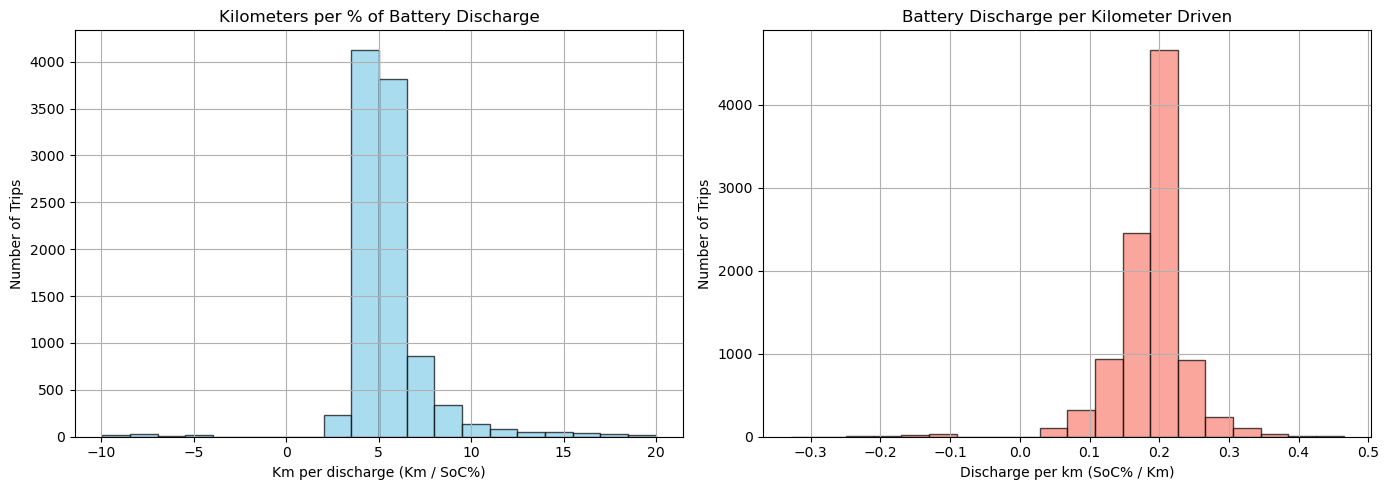

In [32]:
# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Kilometers per % battery
axes[0].hist(
    trip_data['km_per_perc_of_battery'],
    bins=20,
    alpha=0.7,
    color='skyblue',
    edgecolor='black'
)
axes[0].set_title('Kilometers per % of Battery Discharge')
axes[0].set_xlabel('Km per discharge (Km / SoC%)')
axes[0].set_ylabel('Number of Trips')
axes[0].grid(True)

# Discharge per km
axes[1].hist(
    trip_data['discharge_per_km'],
    bins=20,
    alpha=0.7,
    color='salmon',
    edgecolor='black'
)
axes[1].set_title('Battery Discharge per Kilometer Driven')
axes[1].set_xlabel('Discharge per km (SoC% / Km)')
axes[1].set_ylabel('Number of Trips')
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [33]:
trip_data.head()

,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,discharge,avg_speed,km_per_perc_of_battery,discharge_per_km
0,0,0,93.737731,59.886973,-11.375148,0,-11.375148,11.375148,38.332679,5.264720,0.189944
1,0,0,39.313062,25.932388,-4.080228,1,-4.080228,4.080228,39.578278,6.355622,0.157341
2,0,0,173.179648,116.575365,-23.090433,4,-23.090433,23.090433,40.388822,5.048644,0.198073
3,0,0,14.332463,11.291998,-2.930884,5,-2.930884,2.930884,47.271698,3.852762,0.259554
4,0,0,29.522308,11.311860,-3.216118,6,-3.216118,3.216118,22.989788,3.517241,0.284314


In [34]:
max_km = trip_data['km_per_perc_of_battery'].max()
max_km_row = trip_data[trip_data['km_per_perc_of_battery'] == max_km]

print("\n Record with maximum Km/SoC driven:\n")
max_km_row.head()


 Record with maximum Km/SoC driven:



,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,discharge,avg_speed,km_per_perc_of_battery,discharge_per_km
2713,0,0,19.854563,13.017088,-0.652139,4759,-0.652139,0.652139,39.337318,19.960608,0.050099


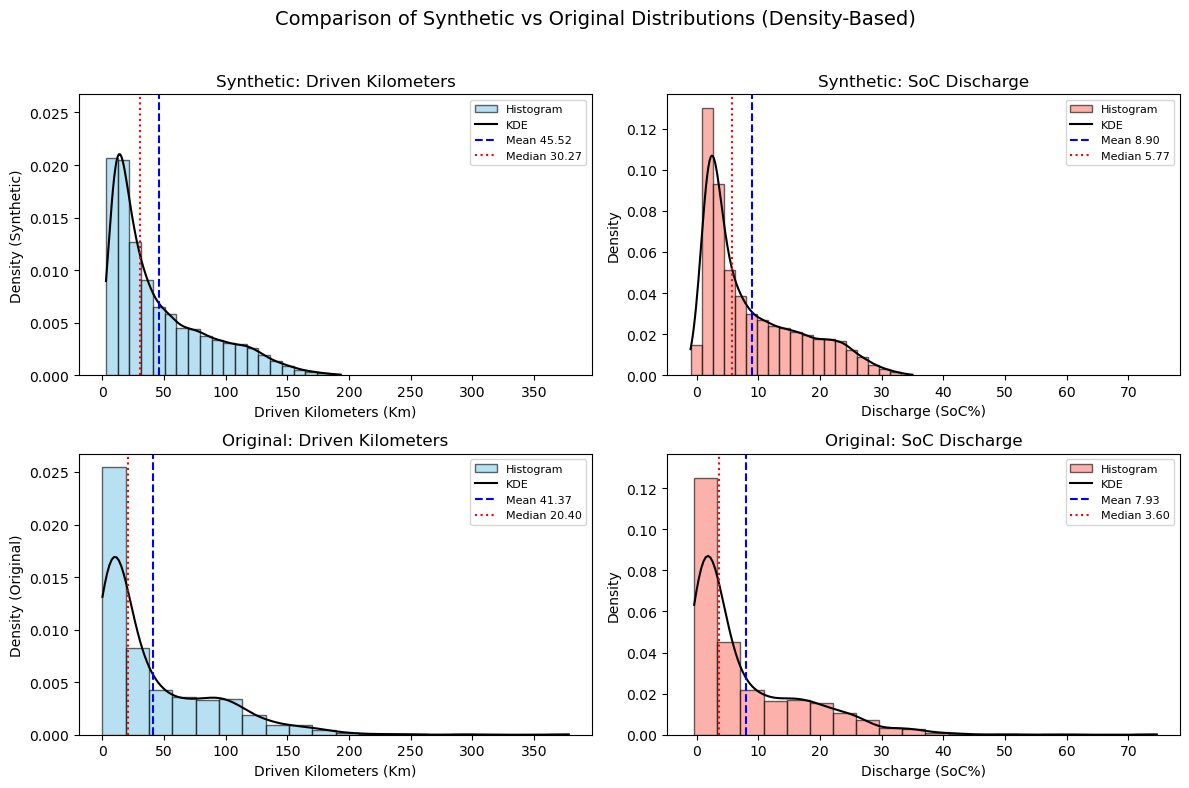

In [69]:
def plot_hist_with_kde(series, ax, color, title, xlabel, bins=20, density=True):
    """Plots histogram + KDE + mean & median, using DENSITY (not frequency)."""
    y = pd.to_numeric(series, errors='coerce').replace([np.inf, -np.inf], np.nan).dropna().values
    if y.size == 0:
        ax.text(0.5, 0.5, "No data", ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title)
        return

    # Histogram as DENSITY
    counts, bin_edges, _ = ax.hist(
        y, bins=bins, density=density, alpha=0.6,
        color=color, edgecolor='black', label='Histogram'
    )

    # KDE on density scale
    try:
        from scipy.stats import gaussian_kde
        kde = gaussian_kde(y)
        x_grid = np.linspace(y.min(), y.max(), 200)
        kde_vals = kde(x_grid)
        ax.plot(x_grid, kde_vals, color='k', lw=1.5, label='KDE')
    except ImportError:
        pass

    # Mean & median lines
    ax.axvline(y.mean(), color='blue', linestyle='--', label=f'Mean {y.mean():.2f}')
    ax.axvline(np.median(y), color='red', linestyle=':', label=f'Median {np.median(y):.2f}')

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)


# --- Create figure with 2 rows (synthetic on top, original on bottom) ---
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex='col', sharey='col')

# Synthetic data (top row)
plot_hist_with_kde(trip_data.get('km_driven', pd.Series(dtype=float)), axes[0, 0],
                   color='skyblue', title='Synthetic: Driven Kilometers', xlabel='Driven Kilometers (Km)')

plot_hist_with_kde(trip_data.get('discharge', pd.Series(dtype=float)), axes[0, 1],
                   color='salmon', title='Synthetic: SoC Discharge', xlabel='Discharge (SoC%)')

# Original data (bottom row)
plot_hist_with_kde(trip_data_original.get('km_driven', pd.Series(dtype=float)), axes[1, 0],
                   color='skyblue', title='Original: Driven Kilometers', xlabel='Driven Kilometers (Km)')

plot_hist_with_kde(trip_data_original.get('discharge', pd.Series(dtype=float)), axes[1, 1],
                   color='salmon', title='Original: SoC Discharge', xlabel='Discharge (SoC%)')

# --- Match axes scales explicitly between synthetic and original ---
for j in range(2):
    xmin = min(axes[0, j].get_xlim()[0], axes[1, j].get_xlim()[0])
    xmax = max(axes[0, j].get_xlim()[1], axes[1, j].get_xlim()[1])
    ymin = min(axes[0, j].get_ylim()[0], axes[1, j].get_ylim()[0])
    ymax = max(axes[0, j].get_ylim()[1], axes[1, j].get_ylim()[1])
    axes[0, j].set_xlim(xmin, xmax)
    axes[1, j].set_xlim(xmin, xmax)
    axes[0, j].set_ylim(ymin, ymax)
    axes[1, j].set_ylim(ymin, ymax)

# --- Show x-axis tick labels for top plots too ---
for ax in axes[0, :]:
    ax.tick_params(labelbottom=True)

# --- Formatting ---
axes[0, 0].set_ylabel("Density (Synthetic)")
axes[1, 0].set_ylabel("Density (Original)")
fig.suptitle("Comparison of Synthetic vs Original Distributions (Density-Based)", fontsize=14, y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


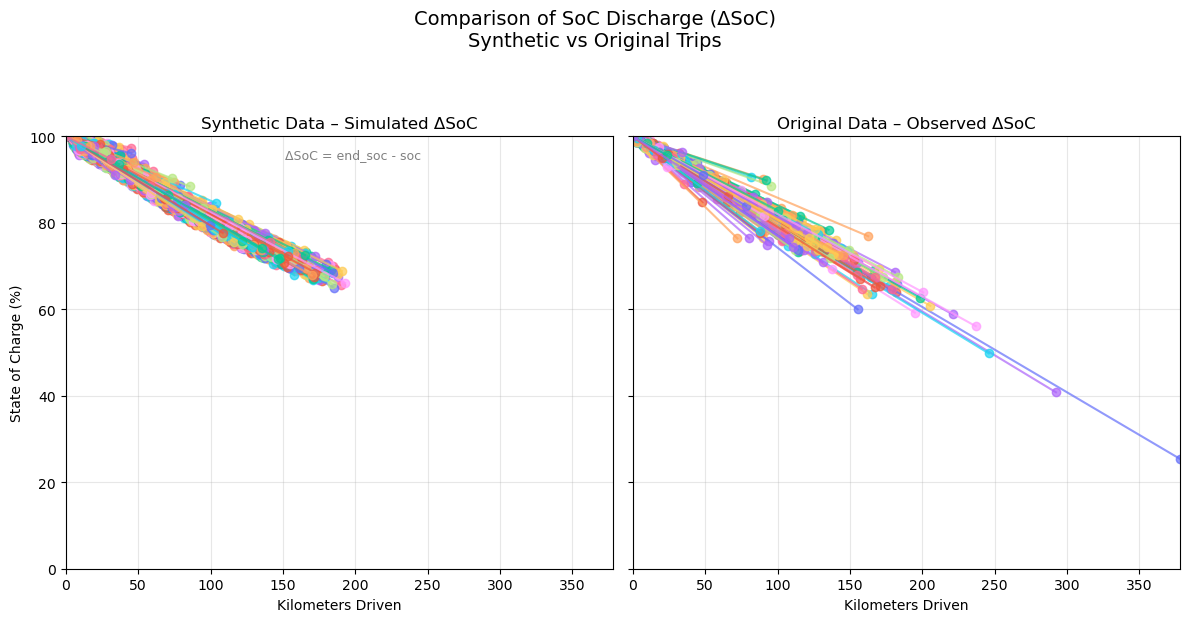

In [64]:
# --- Synthetic data prep ---
trip_data['soc'] = 100
trip_data['end_soc'] = trip_data['soc'] + trip_data['charge']

# --- Shared scales ---
max_km_driven = max(trip_data['km_driven'].max(), trip_data_original['km_driven'].max())

# --- Colors ---
colors = px.colors.qualitative.Plotly

# --- Figure setup ---
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

# ====================================================
# LEFT PANEL – SYNTHETIC
# ====================================================
ax = axes[0]
for i, (_, row) in enumerate(trip_data.iterrows()):
    color = colors[i % len(colors)]
    x_vals = [0, row['km_driven']]
    y_vals = [row['soc'], row['end_soc']]
    ax.plot(x_vals, y_vals, marker='o', alpha=0.7, color=color)

ax.set_title('Synthetic Data – Simulated ΔSoC', fontsize=12)
ax.set_xlabel('Kilometers Driven')
ax.set_ylabel('State of Charge (%)')
ax.set_xlim(0, max_km_driven)
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3)
ax.text(max_km_driven * 0.4, 95, "ΔSoC = end_soc - soc", fontsize=9, color='gray')

# ====================================================
# RIGHT PANEL – ORIGINAL
# ====================================================
ax = axes[1]
for i, (_, row) in enumerate(trip_data_original.iterrows()):
    color = colors[i % len(colors)]
    x_vals = [0, row['km_driven']]
    y_vals = [row['soc'], row['end_soc']]
    ax.plot(x_vals, y_vals, marker='o', alpha=0.7, color=color)

ax.set_title('Original Data – Observed ΔSoC', fontsize=12)
ax.set_xlabel('Kilometers Driven')
ax.set_xlim(0, max_km_driven)
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3)

# ====================================================
# SHARED SETTINGS
# ====================================================
# Reverse y-axis for intuitive "battery discharge" visualization
for ax in axes:
    ax.invert_yaxis()

fig.suptitle('Comparison of SoC Discharge (ΔSoC)\nSynthetic vs Original Trips', fontsize=14, y=1.03)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


In [37]:
trip_data['discharge_per_km'].describe()

count    9857.000000
mean        0.188511
std         0.053476
min        -0.328901
25%         0.169757
50%         0.195296
75%         0.213421
max         0.464691
Name: discharge_per_km, dtype: float64

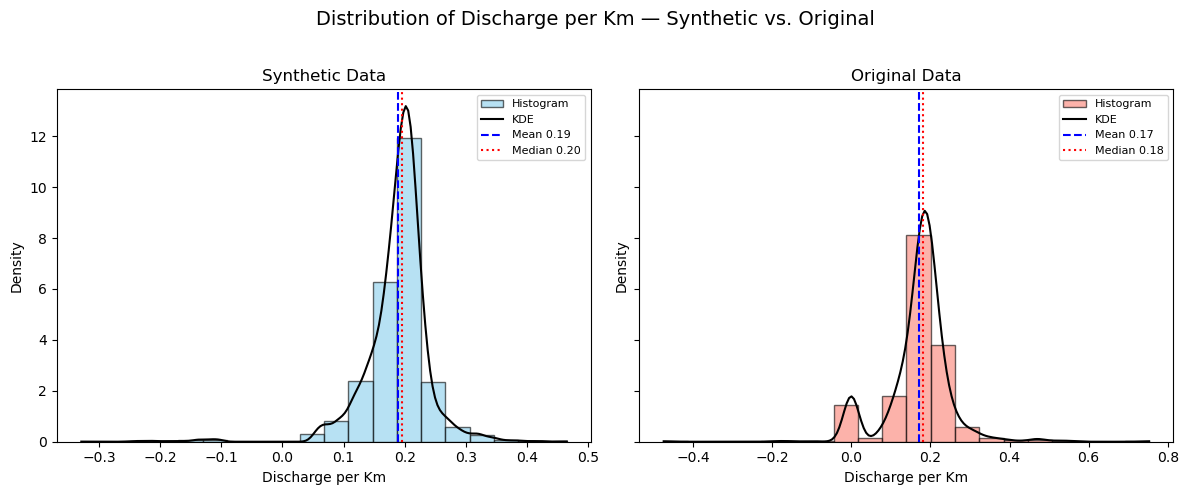

In [72]:
# --- Distribution of Discharge per Km ---
# --- Create side-by-side comparison ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Left panel — synthetic data
plot_hist_with_kde(
    trip_data.get('discharge_per_km', pd.Series(dtype=float)),
    axes[0],
    color='skyblue',
    title='Synthetic Data',
    xlabel='Discharge per Km'
)

# Right panel — original data
plot_hist_with_kde(
    trip_data_original.get('discharge_per_km', pd.Series(dtype=float)),
    axes[1],
    color='salmon',
    title='Original Data',
    xlabel='Discharge per Km',
    density=True
)

# --- Styling ---
fig.suptitle('Distribution of Discharge per Km — Synthetic vs. Original', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## Original dataset

In [39]:
trip_data_original = pd.read_csv('./datasets/new2_vehicle_2_47174e+18.csv')
#trip_data_original = pd.read_csv('./datasets/EV_data.csv')

trip_data_original = trip_data_original[trip_data_original['event'] == 'trip'].reset_index(drop=True)
trip_data_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1207 entries, 0 to 1206
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   vin          1207 non-null   float64
 1   timestamp    1207 non-null   object 
 2   end_time     1207 non-null   object 
 3   odo          1207 non-null   float64
 4   end_odo      1207 non-null   float64
 5   soc          1207 non-null   float64
 6   end_soc      1207 non-null   float64
 7   event        1207 non-null   object 
 8   charge_mode  1207 non-null   object 
dtypes: float64(5), object(4)
memory usage: 85.0+ KB


In [40]:
# Remove duplicates
trip_data_original = trip_data_original.drop_duplicates()

# Print how many rows remain
print(f"Number of rows after removing duplicates: {len(trip_data_original)}")

trip_data_original['km_driven'] = trip_data_original['end_odo'] - trip_data_original['odo']
trip_data_original['discharge'] = trip_data_original['soc'] - trip_data_original['end_soc']

print("📊 Statistics on driven km:\n", trip_data_original['km_driven'].describe())
print("\n🔋 Statistics on discharge:\n", trip_data_original['discharge'].describe())

Number of rows after removing duplicates: 1134
📊 Statistics on driven km:
 count    1134.000000
mean       41.036223
std        46.765638
min         0.000000
25%         8.171871
50%        20.304685
75%        64.996092
max       378.187500
Name: km_driven, dtype: float64

🔋 Statistics on discharge:
 count    1134.000000
mean        7.874339
std         9.234552
min        -0.400000
25%         1.200000
50%         3.600000
75%        12.900000
max        74.600000
Name: discharge, dtype: float64


In [41]:
trip_data_original['km_per_perc_of_battery'] = trip_data_original.apply(
    lambda row: row['km_driven'] / row['discharge'] if row['discharge'] != 0 else 0,
    axis=1
)

trip_data_original['discharge_per_km'] = trip_data_original.apply(
    lambda row: row['discharge'] / row['km_driven'] if row['km_driven'] != 0 else 0,
    axis=1
)


In [42]:
MAX_DISCHARGE_PER_KM = 0.9
##########################################################



anomalous_rows_trip = trip_data_original[(trip_data_original['discharge_per_km'] > MAX_DISCHARGE_PER_KM)]
print(f"Number of anamalous rows: {anomalous_rows_trip.shape[0]}")

trip_data_original = trip_data_original[~(trip_data_original['discharge_per_km'] > MAX_DISCHARGE_PER_KM)].reset_index(drop=True)
anomalous_rows_trip.head(len(anomalous_rows_trip ))

Number of anamalous rows: 7


,vin,timestamp,end_time,odo,end_odo,soc,end_soc,event,charge_mode,km_driven,discharge,km_per_perc_of_battery,discharge_per_km
16,-2.471740e+18,2021-04-29 19:05:00,2021-04-29 19:16:00,2419.812500,2419.84375,25.8,25.4,trip,0,0.031250,0.4,0.078125,12.800000
33,-2.471740e+18,2021-05-02 16:11:00,2021-05-02 16:53:00,2609.625000,2609.65625,34.1,33.3,trip,0,0.031250,0.8,0.039062,25.600000
55,-2.471740e+18,2021-05-05 17:40:00,2021-05-05 18:48:00,2875.703125,2875.75000,39.6,38.8,trip,0,0.046875,0.8,0.058594,17.066667
269,-2.471740e+18,2021-06-08 18:54:00,2021-06-08 18:56:00,11825.156250,11825.65625,50.5,49.8,trip,0,0.500000,0.7,0.714286,1.400000
446,-2.471740e+18,2021-07-11 19:53:00,2021-07-11 20:06:00,21003.656250,21009.34375,62.0,54.0,trip,0,5.687500,8.0,0.710938,1.406593
512,-2.471740e+18,2021-07-17 23:55:00,2021-07-18 01:05:00,23272.312500,23272.64063,41.9,39.2,trip,0,0.328130,2.7,0.121530,8.228446
788,-2.471740e+18,2021-08-10 15:06:00,2021-08-10 15:08:00,31879.125000,31879.32813,36.0,35.6,trip,0,0.203130,0.4,0.507825,1.969182


In [43]:
MIN_DISCHARGE_PER_KM = -1
##########################################################



anomalous_rows_trip = trip_data_original[(trip_data_original['discharge_per_km'] < MIN_DISCHARGE_PER_KM)]
print(f"Number of anamalous rows: {anomalous_rows_trip.shape[0]}")

trip_data_original = trip_data_original[~(trip_data_original['discharge_per_km'] < MIN_DISCHARGE_PER_KM)].reset_index(drop=True)
anomalous_rows_trip.head(len(anomalous_rows_trip ))

Number of anamalous rows: 0


,vin,timestamp,end_time,odo,end_odo,soc,end_soc,event,charge_mode,km_driven,discharge,km_per_perc_of_battery,discharge_per_km


In [44]:
# Identify anomalous records with high km per percentage of battery discharge 
############################
MAX_KM_PER_DISCHARGE = 20 #
############################

anomalous_discharge_records = trip_data_original[trip_data_original['km_per_perc_of_battery'] > MAX_KM_PER_DISCHARGE].sort_values(by='km_per_perc_of_battery', ascending=False)
length = anomalous_discharge_records.shape[0]
print(f"Number of anomalous discharge records: {length}")


trip_data_original = trip_data_original[~(trip_data_original['km_per_perc_of_battery'] > MAX_KM_PER_DISCHARGE)].reset_index(drop=True)
anomalous_discharge_records.head(len(anomalous_discharge_records))



Number of anomalous discharge records: 3


,vin,timestamp,end_time,odo,end_odo,soc,end_soc,event,charge_mode,km_driven,discharge,km_per_perc_of_battery,discharge_per_km
535,-2.471740e+18,2021-07-23 00:31:00,2021-07-23 01:14:00,25236.45313,25248.85123,60.0,59.6,trip,0,12.3981,0.4,30.99525,0.032263
596,-2.471740e+18,2021-07-29 20:46:00,2021-07-29 21:00:00,27163.21875,27172.03125,15.2,14.9,trip,0,8.8125,0.3,29.37500,0.034043
521,-2.471740e+18,2021-07-13 00:08:00,2021-07-13 00:21:00,21541.39063,21550.70313,47.8,47.4,trip,0,9.3125,0.4,23.28125,0.042953


In [45]:
# Identify anomalous records with low km per percentage of battery discharge 
############################
MIN_KM_PER_DISCHARGE = -10 #
############################

anomalous_discharge_records = trip_data_original[trip_data_original['km_per_perc_of_battery'] < MIN_KM_PER_DISCHARGE].sort_values(by='km_per_perc_of_battery', ascending=False)
length = anomalous_discharge_records.shape[0]
print(f"Number of anomalous discharge records: {length}")


trip_data_original = trip_data_original[~(trip_data_original['km_per_perc_of_battery'] < MIN_KM_PER_DISCHARGE)].reset_index(drop=True)
anomalous_discharge_records.head(len(anomalous_discharge_records))

Number of anomalous discharge records: 0


,vin,timestamp,end_time,odo,end_odo,soc,end_soc,event,charge_mode,km_driven,discharge,km_per_perc_of_battery,discharge_per_km


In [46]:
trip_data_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1124 entries, 0 to 1123
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   vin                     1124 non-null   float64
 1   timestamp               1124 non-null   object 
 2   end_time                1124 non-null   object 
 3   odo                     1124 non-null   float64
 4   end_odo                 1124 non-null   float64
 5   soc                     1124 non-null   float64
 6   end_soc                 1124 non-null   float64
 7   event                   1124 non-null   object 
 8   charge_mode             1124 non-null   object 
 9   km_driven               1124 non-null   float64
 10  discharge               1124 non-null   float64
 11  km_per_perc_of_battery  1124 non-null   float64
 12  discharge_per_km        1124 non-null   float64
dtypes: float64(9), object(4)
memory usage: 114.3+ KB


In [47]:
trip_data_original['discharge_per_km'].describe()

count    1124.000000
mean        0.171832
std         0.081194
min        -0.474074
25%         0.151802
50%         0.182523
75%         0.205293
max         0.752941
Name: discharge_per_km, dtype: float64

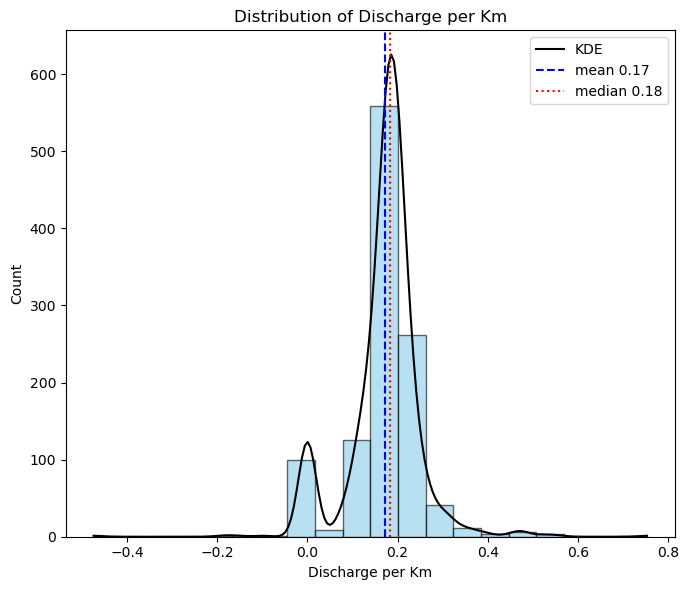

In [48]:
# --- Distribution of Discharge per Km ---
fig, ax = plt.subplots(figsize=(7, 6))

plot_hist_with_kde(trip_data_original.get('discharge_per_km', pd.Series(dtype=float)), ax,
                   color='skyblue', title='Distribution of Discharge per Km', xlabel='Discharge per Km')


plt.tight_layout()
plt.show()

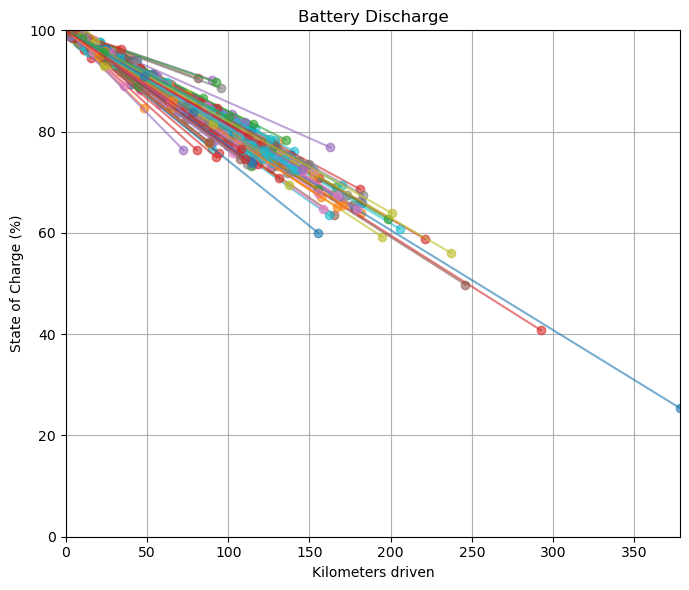

In [49]:
#######################################################
#visualiza delta_soc
trip_data_original['delta_soc'] = trip_data_original['end_soc'] - trip_data_original['soc']
trip_data_original['soc'] = 100
trip_data_original['end_soc'] = trip_data_original['soc'] + trip_data_original['delta_soc'] 



# Max km for x-axis scaling
max_km_driven = trip_data_original['km_driven'].max()

# --- Matplotlib version ---
fig, ax = plt.subplots(figsize=(7, 6))

for _, row in trip_data_original.iterrows():
    x_vals = [0, row['km_driven']]
    y_vals = [row['soc'], row['end_soc']]
    ax.plot(x_vals, y_vals, marker='o', alpha=0.6)

ax.set_title('Battery Discharge')
ax.set_xlabel('Kilometers driven')
ax.set_ylabel('State of Charge (%)')
ax.set_xlim(0, max_km_driven)
ax.set_ylim(0, 100)
ax.grid(True)

plt.tight_layout()
plt.show()


# --- Plotly version ---
colors = px.colors.qualitative.Plotly
fig = go.Figure()

for color_idx, (_, row) in enumerate(trip_data_original.reset_index().iterrows()):
    fig.add_trace(
        go.Scatter(
            x=[0, row['km_driven']],
            y=[row['soc'], row['end_soc']],
            mode='lines+markers',
            opacity=0.5,
            line=dict(color=colors[color_idx % len(colors)], width=2),
            marker=dict(size=6),
            name=f"Trip {row['index']}",
            hovertemplate=(
                f"Trip index: {row['index']}<br>"
                f"SOC start: {row['soc']}%<br>"
                f"SOC end: {row['end_soc']}%<br>"
                f"Km driven: {row['km_driven']} km<br>"
            )
        )
    )

fig.update_xaxes(title_text='Kilometers driven', range=[0, max_km_driven])
fig.update_yaxes(title_text='State of Charge (%)', range=[0, 100])

fig.update_layout(
    title="Battery Discharge",
    height=500,
    width=700,
    showlegend=False,
    hovermode='closest'
)

fig.show()


## Save trip data cleaned

In [50]:
# Save DataFrame
if SAVE:
    trip_data.to_csv(file_path_csv, index=False)

In [51]:
trip_data.head()

,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,discharge,avg_speed,km_per_perc_of_battery,discharge_per_km,soc,end_soc
0,0,0,93.737731,59.886973,-11.375148,0,-11.375148,11.375148,38.332679,5.264720,0.189944,100,88.624852
1,0,0,39.313062,25.932388,-4.080228,1,-4.080228,4.080228,39.578278,6.355622,0.157341,100,95.919772
2,0,0,173.179648,116.575365,-23.090433,4,-23.090433,23.090433,40.388822,5.048644,0.198073,100,76.909567
3,0,0,14.332463,11.291998,-2.930884,5,-2.930884,2.930884,47.271698,3.852762,0.259554,100,97.069116
4,0,0,29.522308,11.311860,-3.216118,6,-3.216118,3.216118,22.989788,3.517241,0.284314,100,96.783882


In [52]:
trip_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9857 entries, 0 to 9856
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   event                   9857 non-null   int64  
 1   charge_mode             9857 non-null   int64  
 2   duration_minutes        9857 non-null   float64
 3   km_driven               9857 non-null   float64
 4   charge                  9857 non-null   float64
 5   id                      9857 non-null   int64  
 6   delta_soc               9857 non-null   float64
 7   discharge               9857 non-null   float64
 8   avg_speed               9857 non-null   float64
 9   km_per_perc_of_battery  9857 non-null   float64
 10  discharge_per_km        9857 non-null   float64
 11  soc                     9857 non-null   int64  
 12  end_soc                 9857 non-null   float64
dtypes: float64(9), int64(4)
memory usage: 1001.2 KB
